# Supermarket Sales Data Analysis

## Project Overview
This project analyzes supermarket sales data to understand customer purchasing behavior, product performance, and sales trends. The analysis focuses on identifying key patterns in the data using statistical analysis and data visualization techniques.

The primary goal of this project is to generate meaningful business insights that can help improve decision-making in areas such as inventory management, marketing strategies, and customer engagement.

## Tools and Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Google Colab

## Key Objectives
- Perform data cleaning and validation
- Conduct exploratory data analysis (EDA)
- Identify sales trends and patterns
- Analyze product and customer performance
- Generate business insights and recommendations

#1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from google.colab import files

sns.set(style="whitegrid")

## Dataset Description

The dataset used in this project contains supermarket transaction records. Each row represents a single transaction made by a customer.

### Dataset Characteristics
- Total Records: 2000
- Total Features: 5

### Columns Description

| Column Name | Description |
|-------------|-------------|
| Date | Date of the transaction |
| Product_Line | Category of product purchased |
| Invoice_ID | Unique identifier for each transaction |
| Quantity | Number of items purchased |
| Total | Total transaction value |

This dataset helps analyze customer purchase behavior and product sales performance.

#2.Load Dataset

In [2]:
df = pd.read_csv("supermarket_sales.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


#3. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

Dataset Shape: (2000, 14)

Column Names:
['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender', 'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date', 'Time', 'Payment', 'Rating']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non-null   object 
 13  Rating     

,Unit_Price,Quantity,Tax,Total,Rating
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,6.957600
std,25.813536,2.6087,2.582829,138.930861,1.730534
min,10.010000,1.0000,1.000000,20.370000,4.000000
25%,33.615000,3.0000,3.317500,137.872500,5.400000
50%,55.610000,5.0000,5.440000,258.040000,6.950000
75%,77.500000,7.0000,7.742500,386.937500,8.400000
max,99.920000,9.0000,10.000000,499.910000,10.000000


#4.Data Quality Checks

In [4]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nUnique Values per Column")
print(df.nunique())

Missing Values
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

Duplicate Rows
0

Unique Values per Column
Invoice_ID       2000
Branch              3
City                3
Customer_Type       2
Gender              2
Product_Line        6
Unit_Price       1811
Quantity            9
Tax               804
Total            1961
Date              364
Time              683
Payment             3
Rating             61
dtype: int64


#5.Data Cleaning

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Create new useful features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()

print("Data cleaning completed")
df.head()

Data cleaning completed


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating,Month,Day
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4,8,Tuesday
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3,2,Thursday
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6,8,Thursday
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5,2,Thursday
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8,7,Tuesday


## Data Cleaning and Preprocessing

Before performing analysis, the dataset was cleaned to ensure data quality and consistency.

### Steps Performed

1. Checked for missing values in the dataset.
2. Identified and removed duplicate records.
3. Converted the **Date** column into a proper datetime format.
4. Created additional features such as **Month** and **Day of Week** to analyze time-based sales trends.

These preprocessing steps ensure that the dataset is reliable and suitable for analysis.

#6.Data Validation

In [7]:
assert df['Total'].min() >= 0, "Sales contains negative values"

print("Data validation passed")

print("Total Sales:", df['Total'].sum())
print("Average Sales:", df['Total'].mean())
print("Median Sales:", df['Total'].median())

Data validation passed
Total Sales: 519280.69
Average Sales: 259.640345
Median Sales: 258.03999999999996


#7. Analysis

#Daily Sales

In [9]:
daily_sales = df.groupby('Date')['Total'].sum()
print(daily_sales.head())

Date
2023-01-01    1145.28
2023-01-02    1631.56
2023-01-03     775.06
2023-01-04    1285.96
2023-01-05     176.61
Name: Total, dtype: float64


#Monthly Sales

In [11]:
monthly_sales = df.groupby('Month')['Total'].sum()
print(monthly_sales)

Month
1     41277.53
2     43104.27
3     45828.31
4     39123.28
5     43962.60
6     42591.34
7     50183.60
8     38313.15
9     42407.20
10    39357.70
11    43728.89
12    49402.82
Name: Total, dtype: float64


#Product Sales

In [13]:
product_sales = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=False)
print(product_sales)

Product_Line
Health & Beauty           96970.32
Sports & Travel           91177.89
Electronic Accessories    88995.19
Home & Lifestyle          86351.63
Food & Beverages          78233.94
Fashion Accessories       77551.72
Name: Total, dtype: float64


#Customer Spending

In [16]:
customer_spending = df.groupby('Invoice_ID')['Total'].sum().sort_values(ascending=False)

print("Top 10 Customers")
print(customer_spending.head(10))

Top 10 Customers
Invoice_ID
INV001169    499.91
INV001119    499.80
INV001498    499.71
INV000790    499.55
INV001651    498.29
INV000942    498.03
INV001823    497.70
INV000051    497.51
INV001924    496.95
INV000311    496.76
Name: Total, dtype: float64


#8.Statistical Analysis

Mean, Median, Std

In [17]:
print("Mean Sales:", df['Total'].mean())
print("Median Sales:", df['Total'].median())
print("Standard Deviation:", df['Total'].std())

Mean Sales: 259.640345
Median Sales: 258.03999999999996
Standard Deviation: 138.93086076882972


Correlation

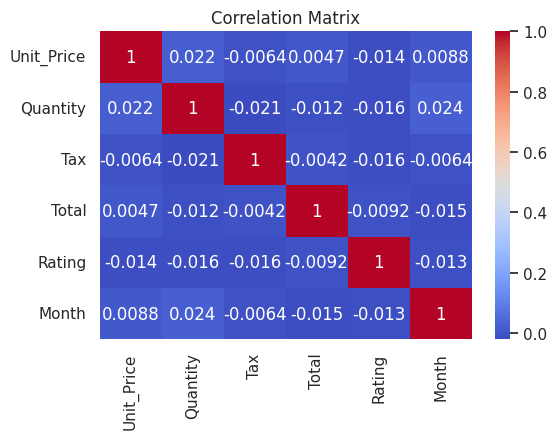

In [18]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [29]:
product_percentage = (product_sales / product_sales.sum()) * 100

print("Product Sales Percentage")
print(product_percentage)

Product Sales Percentage
Product_Line
Health & Beauty           18.673970
Sports & Travel           17.558498
Electronic Accessories    17.138167
Home & Lifestyle          16.629086
Food & Beverages          15.065829
Fashion Accessories       14.934451
Name: Total, dtype: float64


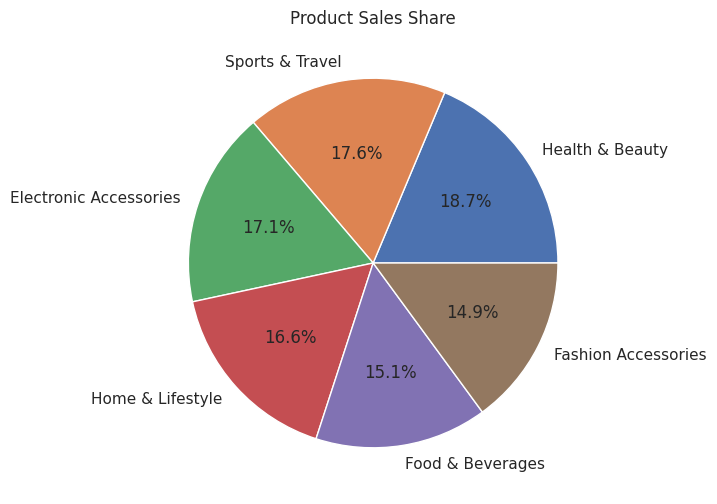

In [30]:
plt.figure(figsize=(8,6))

product_percentage.plot(kind='pie', autopct='%1.1f%%')

plt.title("Product Sales Share")

plt.ylabel("")

plt.show()

## Statistical Analysis

Statistical techniques were applied to summarize and analyze the sales data.

### Key Statistical Measures

- Mean transaction value
- Median transaction value
- Standard deviation of sales
- Correlation between numerical variables

These statistical measures help in understanding the overall distribution and variability of sales transactions.

Customer Spending Segmentation

This shows customer behavior analysis.

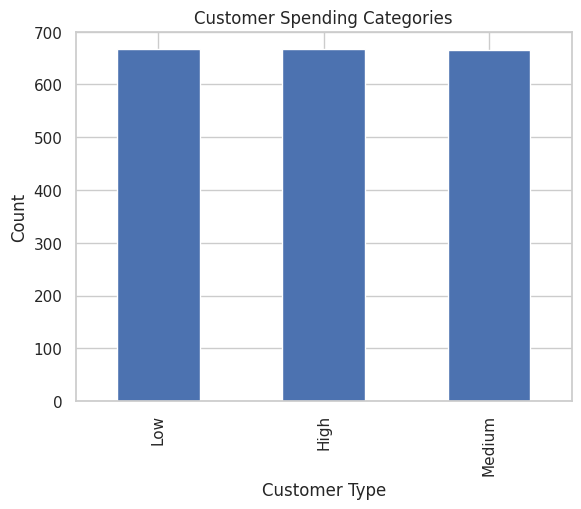

In [32]:
df['CustomerCategory'] = pd.qcut(df['Total'], q=3, labels=['Low','Medium','High'])

df['CustomerCategory'].value_counts().plot(kind='bar')

plt.title("Customer Spending Categories")

plt.xlabel("Customer Type")

plt.ylabel("Count")

plt.show()

Monthly Sales Trend

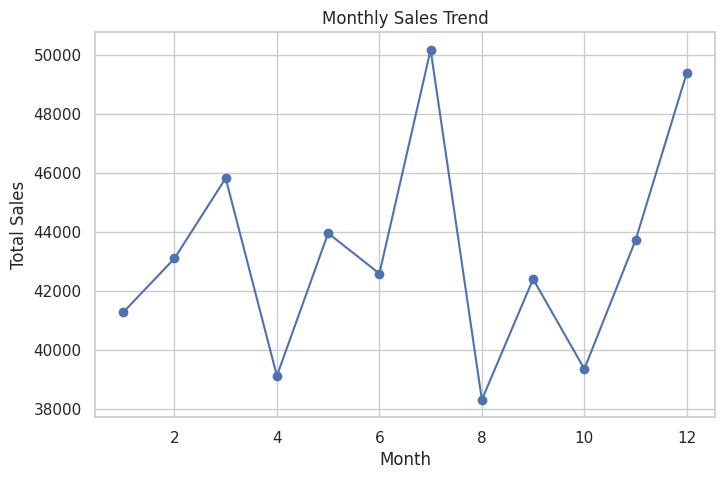

In [31]:
monthly_sales = df.groupby('Month')['Total'].sum()

plt.figure(figsize=(8,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.show()

Visualization 1 (Daily Sales Trend)

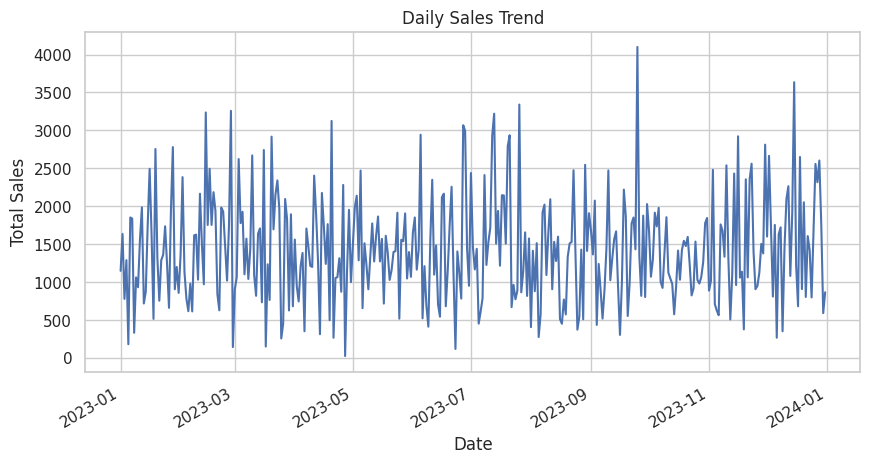

In [19]:
plt.figure(figsize=(10,5))

daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

Visualization 2 (Best Selling Products)

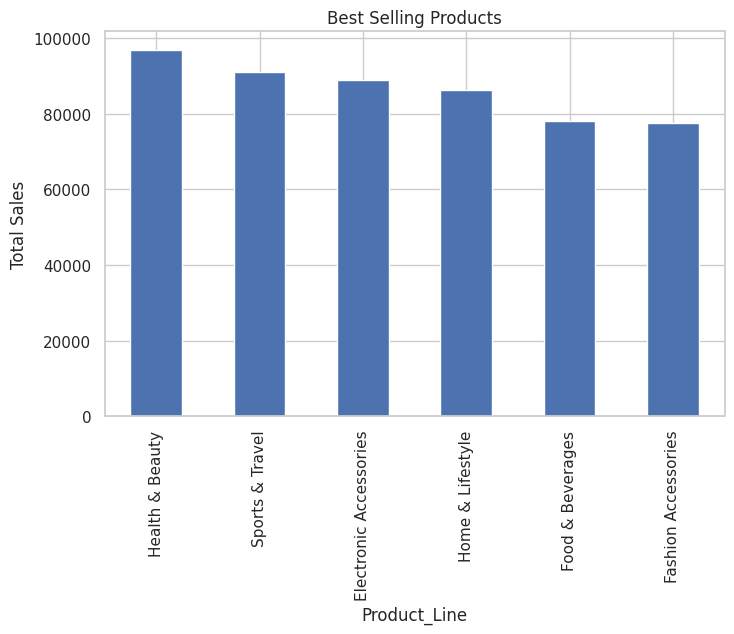

In [20]:
plt.figure(figsize=(8,5))

product_sales.plot(kind='bar')

plt.title("Best Selling Products")
plt.ylabel("Total Sales")

plt.show()

Visualization 3 (Sales Distribution)

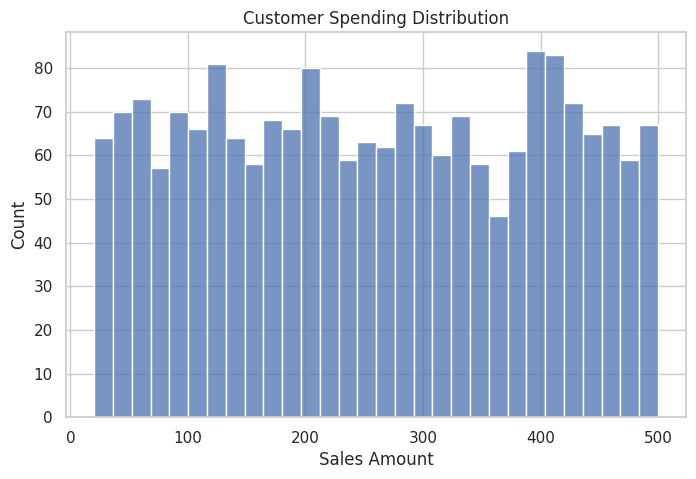

In [22]:

plt.figure(figsize=(8,5))

sns.histplot(df['Total'], bins=30)

plt.title("Customer Spending Distribution")
plt.xlabel("Sales Amount")

plt.show()

Visualization 4 (Sales by Day)

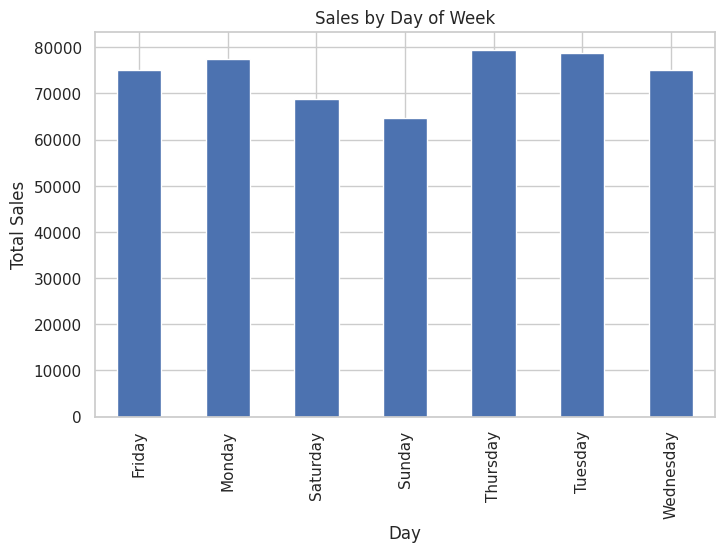

In [24]:
day_sales = df.groupby('Day')['Total'].sum()

plt.figure(figsize=(8,5))

day_sales.plot(kind='bar')

plt.title("Sales by Day of Week")
plt.ylabel("Total Sales")

plt.show()

Visualization 5 (Top Customers)

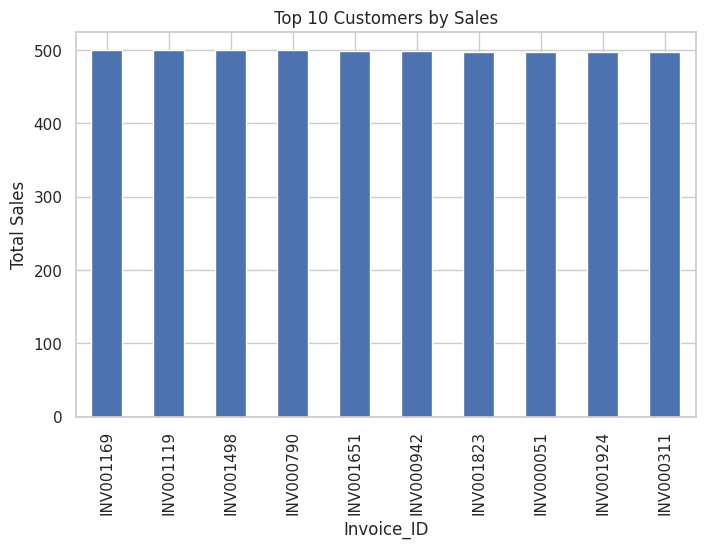

In [25]:
top_customers = customer_spending.head(10)

plt.figure(figsize=(8,5))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.ylabel("Total Sales")

plt.show()

Trend Analysis

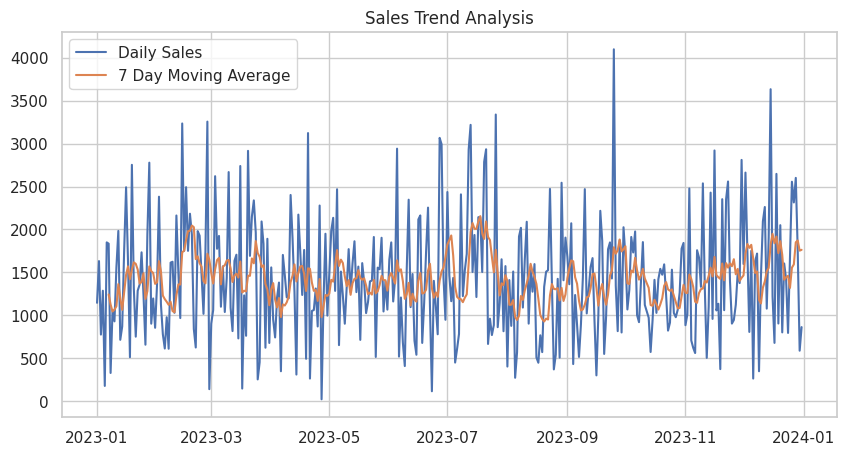

In [26]:
rolling_sales = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(10,5))

plt.plot(daily_sales, label="Daily Sales")
plt.plot(rolling_sales, label="7 Day Moving Average")

plt.title("Sales Trend Analysis")

plt.legend()

plt.show()

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the structure and characteristics of the dataset.

The following analyses were conducted:

- Distribution of sales values
- Product category performance
- Customer spending behavior
- Daily and monthly sales trends
- Sales distribution across days of the week

Various visualizations were used to better understand the relationships within the data.

Business Insights Generator

In [28]:
print("===== SUPERMARKET SALES ANALYSIS REPORT =====")

print("\nTotal Sales:", df['Total'].sum())

print("\nAverage Transaction:", df['Total'].mean())

print("\nBest Selling Product:")
print(product_sales.idxmax())

print("\nHighest Sales Day:")
print(day_sales.idxmax())

print("\nTop Customer:")
print(customer_spending.idxmax())

===== SUPERMARKET SALES ANALYSIS REPORT =====

Total Sales: 519280.69

Average Transaction: 259.640345

Best Selling Product:
Health & Beauty

Highest Sales Day:
Thursday

Top Customer:
INV001169


## Results and Observations

The analysis revealed several important patterns in the supermarket sales data.

- Certain product categories generate significantly higher revenue compared to others.
- Most transactions fall within a moderate spending range, indicating frequent small to medium purchases.
- A small group of customers contributes a significant portion of total revenue.
- Sales fluctuate across different days of the week, indicating specific shopping patterns among customers.
- The rolling average trend shows relatively stable sales with minor fluctuations.

These observations help in understanding how customers interact with the supermarket and which factors influence sales performance.

## Business Insights

Based on the analysis, several key business insights were identified.

- High-performing product categories contribute the majority of total sales.
- Customer spending is not evenly distributed, with a few customers contributing significantly to revenue.
- Weekly sales patterns indicate higher activity on certain days.
- Consistent sales patterns suggest steady demand for supermarket products.

Understanding these insights can help businesses improve inventory management and customer engagement strategies.

## Conclusion

This project analyzed supermarket sales data using Python-based data analysis techniques. The study included data cleaning, exploratory data analysis, statistical evaluation, and visualization to identify meaningful patterns in customer purchasing behavior.

The analysis revealed that product performance, customer spending patterns, and temporal sales trends play a significant role in overall supermarket revenue.

The insights generated from this analysis can help businesses make informed decisions regarding inventory management, marketing strategies, and customer relationship management.

Overall, data-driven analysis can significantly enhance business performance and operational efficiency.